# Q7 — Is deterministic-mixture correction correct?

This notebook isolates the weighting mechanism in a finite model space. The exact target is known, so corrected adaptive estimates can be compared directly with truth without conflating a weighting bug with model-fitting error.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp

rng = np.random.default_rng(7)
prior = np.array([0.55, 0.30, 0.10, 0.05])
score = np.array([0.0, 0.8, 1.4, 2.0])
temperature = 0.8
exact = prior * np.exp(score / temperature)
exact /= exact.sum()
exact

array([0.21568039, 0.31978914, 0.22566454, 0.23886592])

In [2]:
def corrected_estimate(seed, n_rounds=8, round_size=100, defensive=0.2):
    local_rng = np.random.default_rng(seed)
    proposals = []
    samples = []
    for _ in range(n_rounds):
        if not proposals:
            proposal = prior.copy()
        else:
            observed = np.bincount(np.asarray(samples), minlength=len(prior)).astype(float)
            observed /= observed.sum()
            proposal = defensive * prior + (1 - defensive) * observed
        proposals.append(proposal)
        samples.extend(local_rng.choice(len(prior), size=round_size, p=proposal))
    round_mass = np.full(n_rounds, 1 / n_rounds)
    log_weights = []
    for model_index in samples:
        mixture = sum(round_mass[t] * proposals[t][model_index] for t in range(n_rounds))
        log_weights.append(score[model_index] / temperature + np.log(prior[model_index]) - np.log(mixture))
    weights = np.exp(np.asarray(log_weights) - logsumexp(log_weights))
    estimate = np.bincount(np.asarray(samples), weights=weights, minlength=len(prior))
    return estimate

estimates = np.array([corrected_estimate(seed) for seed in range(30)])
print('mean estimate:', estimates.mean(axis=0))
print('absolute bias:', np.abs(estimates.mean(axis=0) - exact))

mean estimate: [0.21936879 0.32977832 0.22923155 0.22162134]
absolute bias: [0.00368839 0.00998917 0.00356701 0.01724458]


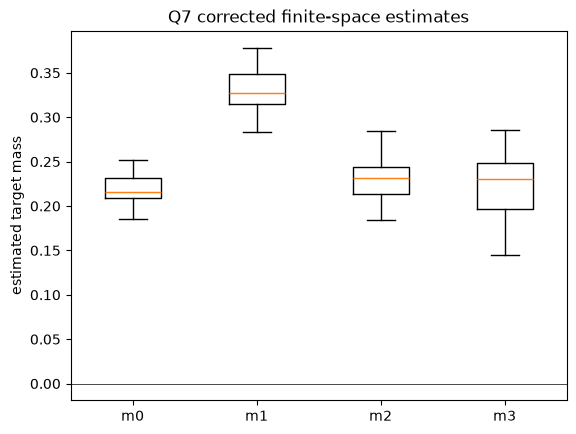

In [3]:
plt.boxplot(estimates, tick_labels=['m0', 'm1', 'm2', 'm3'])
plt.axhline(0, color='black', linewidth=0.5)
plt.ylabel('estimated target mass')
plt.title('Q7 corrected finite-space estimates')
plt.show()
# Extend with more seeds, aggressive proposals, and a deliberately uncorrected run.


## Conclusion from the executed starter run

**Status: not falsified; approximate correction behavior observed.** The exact target family masses were [0.2157, 0.3198, 0.2257, 0.2389]. Across 30 adaptive simulations, the mean corrected estimate was [0.2194, 0.3298, 0.2292, 0.2216], with largest absolute bias 0.0172. This is consistent with finite-sample Monte Carlo error, but a draw-count convergence curve and more seeds are required before claiming unbiasedness.